In [5]:
from google.colab import files
uploaded = files.upload()

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

,ID,시술 시기 코드,시술 당시 나이,임신 시도 또는 마지막 임신 경과 연수,시술 유형,특정 시술 유형,배란 자극 여부,배란 유도 유형,단일 배아 이식 여부,착상 전 유전 검사 사용 여부,...,기증 배아 사용 여부,대리모 여부,PGD 시술 여부,PGS 시술 여부,난자 채취 경과일,난자 해동 경과일,난자 혼합 경과일,배아 이식 경과일,배아 해동 경과일,임신 성공 여부
0,TRAIN_000000,TRZKPL,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0
1,TRAIN_000001,TRYBLT,만45-50세,NaN,IVF,ICSI,0,알 수 없음,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
2,TRAIN_000002,TRVNRY,만18-34세,NaN,IVF,IVF,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,2.0,NaN,0
3,TRAIN_000003,TRJXFG,만35-37세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,NaN,NaN,0
4,TRAIN_000004,TRVNRY,만18-34세,NaN,IVF,ICSI,1,기록되지 않은 시행,0.0,NaN,...,0.0,0.0,NaN,NaN,0.0,NaN,0.0,3.0,NaN,0


In [ ]:
# 타겟 확인
df['임신 성공 여부'].value_counts()
df['임신 성공 여부'].value_counts(normalize=True)

,proportion
임신 성공 여부,
0,0.741651
1,0.258349


In [ ]:
# 컬럼 타입 확인
df.dtypes.value_counts()

,count
float64,29
object,21
int64,19


In [ ]:
# 결측치 TOP20
df.isnull().sum().sort_values(ascending=False).head(20)

,0
난자 해동 경과일,254915
PGS 시술 여부,254422
PGD 시술 여부,254172
착상 전 유전 검사 사용 여부,253633
임신 시도 또는 마지막 임신 경과 연수,246981
배아 해동 경과일,215982
난자 채취 경과일,57488
난자 혼합 경과일,53735
배아 이식 경과일,43566
미세주입 후 저장된 배아 수,6291


In [ ]:
df['시술 유형'].value_counts()

,count
시술 유형,
IVF,250060
DI,6291


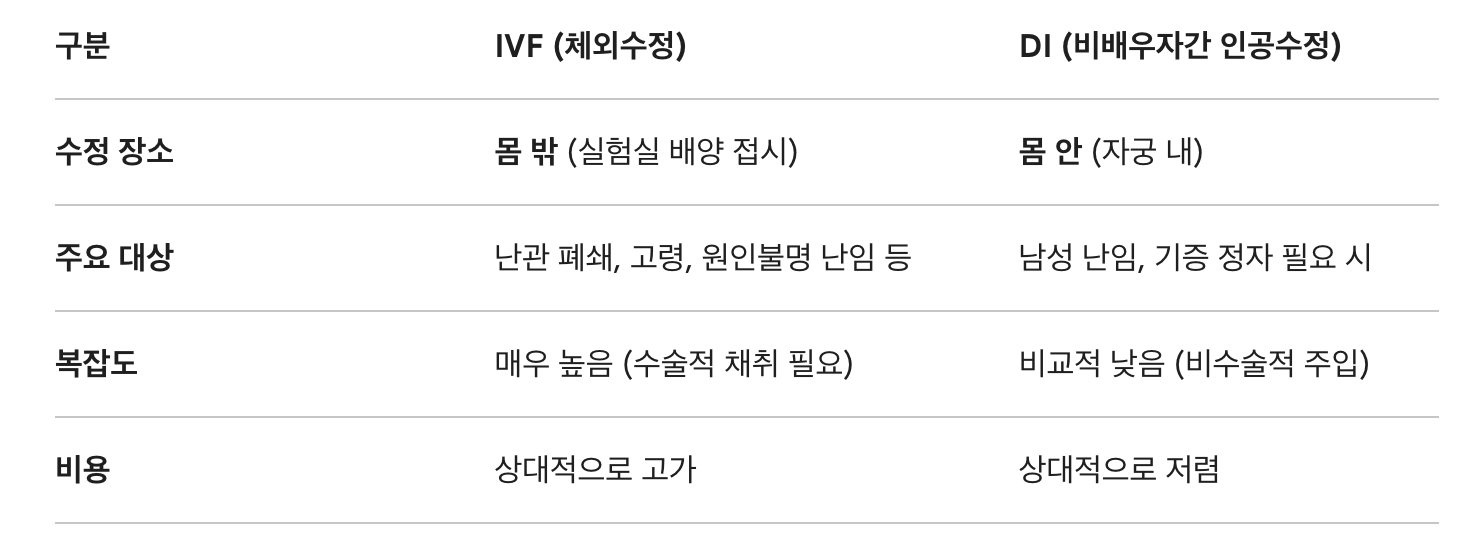


In [ ]:
pd.crosstab(df['시술 유형'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
시술 유형,,
DI,0.871086,0.128914
IVF,0.738395,0.261605


In [ ]:
# 결측 비율 보기
missing_ratio = df.isnull().mean().sort_values(ascending=False)
missing_ratio.head(20)

,0
난자 해동 경과일,0.994398
PGS 시술 여부,0.992475
PGD 시술 여부,0.991500
착상 전 유전 검사 사용 여부,0.989397
임신 시도 또는 마지막 임신 경과 연수,0.963449
배아 해동 경과일,0.842525
난자 채취 경과일,0.224255
난자 혼합 경과일,0.209615
배아 이식 경과일,0.169947
미세주입 후 저장된 배아 수,0.024541


난자 해동 경과일 → 99.4% 결측
PGS → 99.2% 결측
PGD → 99.1% 결측       ---> 대부분의 환자가 해당 시술을 안했음을 알 수 있음

In [ ]:
# 결측치 vs 타겟 관계 보기
df['PGS 시술 여부'].isnull().groupby(df['임신 성공 여부']).mean()

,PGS 시술 여부
임신 성공 여부,
0,0.991947
1,0.993990


PGS 시술 여부는 결측 비율이 매우 높고,
결측 여부와 임신 성공 간 차이도 거의 없어서
예측 변수로서 영향력은 크지 않을 가능성

In [ ]:
# 컬럼명 전체 확인
df.columns.tolist()

['ID',
 '시술 시기 코드',
 '시술 당시 나이',
 '임신 시도 또는 마지막 임신 경과 연수',
 '시술 유형',
 '특정 시술 유형',
 '배란 자극 여부',
 '배란 유도 유형',
 '단일 배아 이식 여부',
 '착상 전 유전 검사 사용 여부',
 '착상 전 유전 진단 사용 여부',
 '남성 주 불임 원인',
 '남성 부 불임 원인',
 '여성 주 불임 원인',
 '여성 부 불임 원인',
 '부부 주 불임 원인',
 '부부 부 불임 원인',
 '불명확 불임 원인',
 '불임 원인 - 난관 질환',
 '불임 원인 - 남성 요인',
 '불임 원인 - 배란 장애',
 '불임 원인 - 여성 요인',
 '불임 원인 - 자궁경부 문제',
 '불임 원인 - 자궁내막증',
 '불임 원인 - 정자 농도',
 '불임 원인 - 정자 면역학적 요인',
 '불임 원인 - 정자 운동성',
 '불임 원인 - 정자 형태',
 '배아 생성 주요 이유',
 '총 시술 횟수',
 '클리닉 내 총 시술 횟수',
 'IVF 시술 횟수',
 'DI 시술 횟수',
 '총 임신 횟수',
 'IVF 임신 횟수',
 'DI 임신 횟수',
 '총 출산 횟수',
 'IVF 출산 횟수',
 'DI 출산 횟수',
 '총 생성 배아 수',
 '미세주입된 난자 수',
 '미세주입에서 생성된 배아 수',
 '이식된 배아 수',
 '미세주입 배아 이식 수',
 '저장된 배아 수',
 '미세주입 후 저장된 배아 수',
 '해동된 배아 수',
 '해동 난자 수',
 '수집된 신선 난자 수',
 '저장된 신선 난자 수',
 '혼합된 난자 수',
 '파트너 정자와 혼합된 난자 수',
 '기증자 정자와 혼합된 난자 수',
 '난자 출처',
 '정자 출처',
 '난자 기증자 나이',
 '정자 기증자 나이',
 '동결 배아 사용 여부',
 '신선 배아 사용 여부',
 '기증 배아 사용 여부',
 '대리모 여부',
 'PGD 시술 여부',
 'PGS 시술 여부',
 '난자 채취 경과일',
 '난자 해동 경과일',
 '난자

In [ ]:
# 의미있는 변수 찾기
import pandas as pd

cols = [
    '시술 유형',
    '특정 시술 유형',
    '시술 당시 나이',
    '단일 배아 이식 여부',
    '배아 생성 주요 이유'
]

for col in cols:
    print(f"\n===== {col} =====")
    print(pd.crosstab(df[col], df['임신 성공 여부'], normalize='index'))


===== 시술 유형 =====
임신 성공 여부         0         1
시술 유형                       
DI        0.871086  0.128914
IVF       0.738395  0.261605

===== 특정 시술 유형 =====
임신 성공 여부                                    0         1
특정 시술 유형                                               
FER                                  0.666667  0.333333
GIFT                                 1.000000  0.000000
Generic DI                           0.830986  0.169014
ICI                                  0.864583  0.135417
ICSI                                 0.727175  0.272825
ICSI / AH                            0.782835  0.217165
ICSI / AH:Unknown                    0.500000  0.500000
ICSI / BLASTOCYST                    0.643257  0.356743
ICSI / BLASTOCYST :ICSI              0.000000  1.000000
ICSI / BLASTOCYST :IVF / BLASTOCYST  0.750000  0.250000
ICSI / BLASTOCYST:IVF / BLASTOCYST   0.666667  0.333333
ICSI:ICSI                            0.990061  0.009939
ICSI:IVF                             0.765178  0.234822
ICS

In [ ]:
# 나이 따로보자
print(pd.crosstab(df['시술 당시 나이'], df['임신 성공 여부'], normalize='index'))

임신 성공 여부         0         1
시술 당시 나이                    
만18-34세   0.677378  0.322622
만35-37세   0.721599  0.278401
만38-39세   0.782862  0.217138
만40-42세   0.840607  0.159393
만43-44세   0.881988  0.118012
만45-50세   0.832321  0.167679
알 수 없음    1.000000  0.000000


In [ ]:
# 시술 횟수 vs 성공
print(pd.crosstab(df['총 시술 횟수'], df['임신 성공 여부'], normalize='index').head(10))

임신 성공 여부         0         1
총 시술 횟수                     
0회        0.709013  0.290987
1회        0.750048  0.249952
2회        0.755834  0.244166
3회        0.763646  0.236354
4회        0.772208  0.227792
5회        0.784208  0.215792
6회 이상     0.796700  0.203300


In [ ]:
# 배아 관련
print(pd.crosstab(df['이식된 배아 수'], df['임신 성공 여부'], normalize='index'))

임신 성공 여부         0         1
이식된 배아 수                    
0.0       0.999179  0.000821
1.0       0.686452  0.313548
2.0       0.688908  0.311092
3.0       0.831532  0.168468


In [ ]:
# 상관관계
corr = df.corr(numeric_only=True)['임신 성공 여부'].sort_values(ascending=False)
print(corr.head(10))

임신 성공 여부            1.000000
이식된 배아 수            0.157487
배아 이식 경과일           0.148590
총 생성 배아 수           0.146116
단일 배아 이식 여부         0.132635
혼합된 난자 수            0.116136
파트너 정자와 혼합된 난자 수    0.104902
미세주입에서 생성된 배아 수     0.090275
수집된 신선 난자 수         0.083023
미세주입 배아 이식 수        0.074351
Name: 임신 성공 여부, dtype: float64


In [ ]:
print(pd.crosstab(df['시술 유형'], df['임신 성공 여부'], normalize='index'))

임신 성공 여부         0         1
시술 유형                       
DI        0.871086  0.128914
IVF       0.738395  0.261605


In [ ]:
pd.crosstab(df['정자 출처'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
정자 출처,,
기증 제공,0.756256,0.243744
미할당,0.893443,0.106557
배우자 및 기증 제공,1.000000,0.000000
배우자 제공,0.739833,0.260167


1. 미할당 → 성공 10.6% (매우 낮음) - 미할당 의미는 진짜 결측치 가능성 높음(기록누착,시스템 문제 등), 특수 케이스(시술 중단,데이터 incomplete,실험/비정형 케이스)나 임상적으로 복잡한 케이스 등으로 추정 ---->미할당 카테고리는 실제 임상적 의미보다는
데이터 누락 또는 기록 문제일 가능성이 있어서
별도로 처리하거나 제외 검토가 필요해 보임
2. 배우자 및 기증 제공 카테고리는 샘플 수가 매우 적어서
통계적으로 의미 있는 패턴으로 보기 어렵고,
모델에서는 별도 처리 또는 통합이 필요해보임

In [ ]:
# 불임 원인 그룹
cols = [c for c in df.columns if '불임 원인' in c]

for col in cols:
    print(f"\n===== {col} =====")
    print(pd.crosstab(df[col], df['임신 성공 여부'], normalize='index'))


===== 남성 주 불임 원인 =====
임신 성공 여부           0         1
남성 주 불임 원인                    
0           0.740525  0.259475
1           0.780027  0.219973

===== 남성 부 불임 원인 =====
임신 성공 여부           0         1
남성 부 불임 원인                    
0           0.740842  0.259158
1           0.802499  0.197501

===== 여성 주 불임 원인 =====
임신 성공 여부           0         1
여성 주 불임 원인                    
0           0.740408  0.259592
1           0.780853  0.219147

===== 여성 부 불임 원인 =====
임신 성공 여부           0         1
여성 부 불임 원인                    
0           0.740864  0.259136
1           0.804205  0.195795

===== 부부 주 불임 원인 =====
임신 성공 여부           0         1
부부 주 불임 원인                    
0           0.740348  0.259652
1           0.779757  0.220243

===== 부부 부 불임 원인 =====
임신 성공 여부           0         1
부부 부 불임 원인                    
0           0.741019  0.258981
1           0.813084  0.186916

===== 불명확 불임 원인 =====
임신 성공 여부          0         1
불명확 불임 원인                    
0          0.742024  0.257976

1. 기본 성공율 :  약 25~26% (대부분 변수에서 0일때,25.8% 정도)

In [ ]:
df[['여성 주 불임 원인','여성 부 불임 원인','남성 주 불임 원인','남성 부 불임 원인']].sum()

,0
여성 주 불임 원인,7876
여성 부 불임 원인,3187
남성 주 불임 원인,7310
남성 부 불임 원인,3362


In [ ]:
df[['여성 주 불임 원인','여성 부 불임 원인','남성 주 불임 원인','남성 부 불임 원인']].head(20)

,여성 주 불임 원인,여성 부 불임 원인,남성 주 불임 원인,남성 부 불임 원인
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0
5,0,0,0,0
6,0,0,0,0
7,0,0,0,0
8,0,0,0,0
9,0,0,0,0


In [ ]:
df['불임 원인 개수'] = (
    df['남성 주 불임 원인'] +
    df['남성 부 불임 원인'] +
    df['여성 주 불임 원인'] +
    df['여성 부 불임 원인'] +
    df['부부 주 불임 원인'] +
    df['부부 부 불임 원인']
)

In [ ]:
pd.crosstab(df['불명확 불임 원인'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
불명확 불임 원인,,
0,0.742024,0.257976
1,0.740537,0.259463


불명확 불임 원인
0 → 성공 25.8%

1 → 성공 25.9%

In [ ]:
df[
    (df['여성 주 불임 원인']==0) &
    (df['남성 주 불임 원인']==0) &
    (df['부부 주 불임 원인']==0)
]['불명확 불임 원인'].value_counts()

,count
불명확 불임 원인,
0,184954
1,62344


주 원인 (여성/남성/부부) 다 0인 경우
→ 불명확 불임 원인 = 1도 꽤 많음

0 = “원인 없음” + “기록 없음” + “기타”

불명확 불임 원인은 임신 성공률에 큰 차이를 보이지 않았으며,
주요 불임 원인 변수들과의 관계를 보면
0 값이 단순히 ‘원인 없음’을 의미하기보다는
기록 누락 또는 정의상의 한계가 포함된 값일 가능성이 있음

In [ ]:
cols = [
    '여성 주 불임 원인',
    '여성 부 불임 원인',
    '남성 주 불임 원인',
    '남성 부 불임 원인',
    '부부 주 불임 원인',
    '부부 부 불임 원인'
]

df[cols] = df[cols].fillna(0)
df['불임 원인 개수'] = df[cols].sum(axis=1)

pd.crosstab(df['불임 원인 개수'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
불임 원인 개수,,
0,0.739585,0.260415
1,0.800000,0.200000
2,0.748000,0.252000
3,0.787562,0.212438
4,0.800000,0.200000
6,1.000000,0.000000


불임 원인 갯수와 임신 성공여부는 선형관계가 아님.
1. 데이터 정의 :  0이 원인없음만을 의미하는게 아니라 기록없음이 포함되므로
2. 원인의 질quality  더 중요 : 개수보다는 종류(질)
3. 샘플 수 부족: 4개 6개 그룹은 샘플 수 매우 적어 노이즈임
--> 불임 원인 갯수 보다는 원인의 종류와 치료 가능성이 더 중요한 요인일 가능성을 시사함


In [ ]:
cols = [
    '불임 원인 - 남성 요인',
    '불임 원인 - 배란 장애',
    '불임 원인 - 난관 질환'
]

for col in cols:
    print(col)
    print(pd.crosstab(df[col], df['임신 성공 여부'], normalize='index'))
    print('-'*30)

불임 원인 - 남성 요인
임신 성공 여부              0         1
불임 원인 - 남성 요인                    
0              0.754433  0.245567
1              0.720110  0.279890
------------------------------
불임 원인 - 배란 장애
임신 성공 여부              0         1
불임 원인 - 배란 장애                    
0              0.745892  0.254108
1              0.713367  0.286633
------------------------------
불임 원인 - 난관 질환
임신 성공 여부              0         1
불임 원인 - 난관 질환                    
0              0.741555  0.258445
1              0.742245  0.257755
------------------------------


남성 요인

0 → 24.6%

1 → 27.9%

배란 장애

0 → 25.4%

1 → 28.6%

난관 질환

0 → 25.8%

1 → 25.7%
 1. 남성 요인이 있을 때 임신 성공율이 높다는 것은 치료가 잘되는 문제라는 뜻임
 2. 배란 장애 시 임신 성공율이 높다는 것은 치료가 잘되는 문제라는 뜻임
 “치료 가능한 불임 원인 → 성공률 높음”

 3. 그러나 난관 질환은 임신 성공율에 별 차이가 없어 변수 중요도가 낮을 가능성이 큼

In [ ]:
pd.crosstab(df['배란 유도 유형'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
배란 유도 유형,,
기록되지 않은 시행,0.731593,0.268407
생식선 자극 호르몬,0.000000,1.000000
세트로타이드 (억제제),1.000000,0.000000
알 수 없음,0.773245,0.226755


In [ ]:
df['배란 유도 유형'].value_counts()

,count
배란 유도 유형,
기록되지 않은 시행,194432
알 수 없음,61917
세트로타이드 (억제제),1
생식선 자극 호르몬,1


In [ ]:
pd.crosstab(df['단일 배아 이식 여부'], df['임신 성공 여부'], normalize='index')

임신 성공 여부,0,1
단일 배아 이식 여부,,
0.0,0.770567,0.229433
1.0,0.632770,0.367230


단일 배아 이식 여부

0 → 성공률 22.9%

1 → 성공률 36.7%

단일 배아 이식이 성공률 높게 나오냐

이유 1: 좋은 환자에게 선택됨

젊은 환자,
배아 quality 좋은 경우

그래서 이미 성공 가능성이 높은 그룹  -> 이것은 '원인'이 아니라 '선택결과'에 가까움
단일 배아 이식 여부 = 강력한 예측 변수 (하지만 인과 아님)
====이건 data leakage는 아니지만 post-decision bias 가능성 있음

EDA 끝    BASELINE MODEL  시작


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

In [6]:
import pandas as pd

df = pd.read_csv('data/train.csv')

In [7]:
# ======================
# BASELINE MODEL
# ======================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

df_model = df.copy()

X = df_model.drop(columns=['임신 성공 여부', 'ID'])
y = df_model['임신 성공 여부']

# 범주형 인코딩
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# 결측치 처리
X = X.fillna(-1)

# 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 모델
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 평가
pred = model.predict_proba(X_val)[:, 1]
print("AUC:", roc_auc_score(y_val, pred))

AUC: 0.7217431512237072
